In [1]:
import pickle 
import ROOT
import numpy as np
import hist
import matplotlib.pyplot as plt
import mplhep as hep


In [2]:
# load pickled datasets (pickle already imported in another cell)
paths = {
    "data1": "ROOT_files/pythia_ht_LO_output_no_syst.pkl",
    "data2": "ROOT_files/herwig_ht_LO_output_no_syst.pkl",
    "data3": "ROOT_files/herwig_ht_LO_output_no_syst.pkl",
}

for name, p in paths.items():
    try:
        with open(p, "rb") as f:
            globals()[name] = pickle.load(f)
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find file: {p}")
    except Exception as e:
        raise RuntimeError(f"Failed to load {p}: {e}")

# quick sanity print
print("Loaded:", ", ".join(f"{n} (type={type(globals()[n]).__name__})" for n in paths))

Loaded: data1 (type=dict_accumulator), data2 (type=dict_accumulator), data3 (type=dict_accumulator)


In [3]:
closure = False

In [4]:
data3.keys()

dict_keys(['ptjet_mjet_u_reco', 'ptjet_mjet_g_reco', 'response_matrix_u', 'response_matrix_g', 'ptjet_mjet_u_gen', 'ptjet_mjet_g_gen', 'ptz_mz_reco', 'sumw', 'nev', 'cutflow'])

In [5]:
rebin_factor = 2
rebin_factor_gen  = 2
groomed = True
if groomed:
    pythia4d = data1['response_matrix_g'].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    herwig4d = data2['response_matrix_g'].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    pythia2d = data1['response_matrix_g'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    herwig2d = data2['response_matrix_g'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    data2d = data3['ptjet_mjet_g_reco'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]


    mass_start = 0
    mass_end = 200

    pythia4d = pythia4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    herwig4d = herwig4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    pythia2d = pythia2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    herwig2d = herwig2d[:, hist.loc(mass_start):hist.loc(mass_end)]
if not groomed:
    pythia4d = data1['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    herwig4d = data2['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    pythia2d = data1['response_matrix_u'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    herwig2d = data2['response_matrix_u'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    data2d = data3['ptjet_mjet_u_reco'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]

    mass_start = 0
    mass_end = 200

    pythia4d = pythia4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    herwig4d = herwig4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    pythia2d = pythia2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    herwig2d = herwig2d[:, hist.loc(mass_start):hist.loc(mass_end)]

# pythia4d = data1['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')
# herwig4d = data2['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')
# pythia2d = data1['response_matrix_u'].project('ptreco', 'mreco')
# herwig2d = data1['response_matrix_u'].project('ptreco', 'mreco')

In [6]:
pnp = pythia4d.values().reshape(pythia4d.values().shape[0]*pythia4d.values().shape[1], pythia4d.values().shape[2]*pythia4d.values().shape[3])
hnp = pythia4d.values().reshape(pythia4d.values().shape[0]*pythia4d.values().shape[1], pythia4d.values().shape[2]*pythia4d.values().shape[3])

/tmp/ipykernel_154683/2122312333.py:2: RuntimeWarning: invalid value encountered in divide
  pnp_norm = pnp / np.sum(pnp, axis=1, keepdims=True)


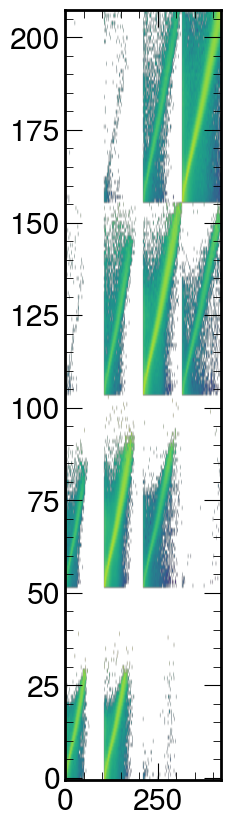

In [7]:
hep.style.use("CMS")
pnp_norm = pnp / np.sum(pnp, axis=1, keepdims=True)
plt.imshow(pnp_norm, origin = 'lower', aspect = 10, norm = 'log')

In [8]:
mass_edges_reco = pythia4d.axes['mreco'].edges.tolist()
mass_edges_gen = pythia4d.axes['mgen'].edges.tolist()


In [9]:
#!/usr/bin/env python3
import random
from array import array
import ROOT as r
import numpy as _np
r.gROOT.SetBatch(True)
random.seed(42)

# ----------------------------
# 1) Define pT slices and mass edges (edit for your analysis)
# ----------------------------
pt_slices = [(0.0,200.0),(200.,290.), (290.,400.), (400.,13000.)]
mreco_edges_pt = [
    mass_edges_reco,
    mass_edges_reco,  # slice 0
    mass_edges_reco,          # slice 1
    mass_edges_reco,                   # slice 2
]
mgen_edges_pt = [
    mass_edges_gen,
    mass_edges_gen,  # slice 0
    mass_edges_gen,          # slice 1
    mass_edges_gen,                   # slice 2
]
assert len(pt_slices) == len(mreco_edges_pt)

# # resolutions (toy)
# rel_pt_res = [0.10, 0.08, 0.06]
# abs_m_res  = [4.0,  5.0,  6.0]

def find_slice(pt):
    for i,(lo,hi) in enumerate(pt_slices):
        if lo <= pt < hi: return i
    return None

# def sample_truth_pt():
#     # ~ pT^{-4} between 200 and 1000
#     n, pmin, pmax = 4.0, 200.0, 1000.0
#     u = random.random()
#     a, b = pmin**(1-n), pmax**(1-n)
#     return (a + u*(b-a))**(1/(1-n))

# def sample_truth_mass(i):
#     lo, hi = mass_edges[i][0], mass_edges[i][-1]
#     mode, scale = [14.,22.,30.][i], [8.,10.,12.][i]
#     for _ in range(1000):
#         m = max(0.0, random.expovariate(1.0/scale)) + 0.5*mode
#         if lo <= m < hi: return m
#     return min(max(mode, lo), hi-1e-6)

# def smear_pt(pt,i):   return max(0.0, random.gauss(pt, rel_pt_res[i]*pt))
# def smear_m(m,i):     return max(0.0, random.gauss(m,  abs_m_res[i]))

# ----------------------------
# 2) Build binning trees with named nodes
#    truth:  root("truth") -> signal -> pt0,pt1,pt2 (each has "mass" axis)
#    reco :  root("reco")  -> primary -> pt0,pt1,pt2 (each has "mass" axis)
# ----------------------------
truth_root = r.TUnfoldBinning("truth")
reco_root  = r.TUnfoldBinning("reco")

truth_signal = truth_root.AddBinning("signal")
reco_primary = reco_root .AddBinning("primary")

truth_nodes, reco_nodes = [], []
# use separate mass-edge lists for truth (gen) and reco; keep `mass_edges` pointing to gen for sample_truth_mass
mass_edges = mgen_edges_pt

for i in range(len(pt_slices)):
    a_gen  = array('d', mgen_edges_pt[i])
    a_reco = array('d', mreco_edges_pt[i])
    tnode = truth_signal.AddBinning(f"pt{i}")
    rnode = reco_primary.AddBinning(f"pt{i}")
    # 1D mass axis inside each slice; exclude under/overflow bins here
    tnode.AddAxis("mass", len(mgen_edges_pt[i]) - 1, a_gen,  False, False)
    rnode.AddAxis("mass", len(mreco_edges_pt[i]) - 1, a_reco, False, False)
    truth_nodes.append(tnode)
    reco_nodes .append(rnode)

# ----------------------------
# 3) Book histograms consistent with the binning
# ----------------------------
hRecoData   = reco_root .CreateHistogram("hRecoData")    # TH1D over global reco bins
hTruthPrior = truth_root.CreateHistogram("hTruthPrior")  # TH1D over global truth bins
hResponse   = r.TUnfoldBinning.CreateHistogramOfMigrations( truth_root, reco_root, "hResponse")  # TH2D (x=reco, y=truth)

# ----------------------------
# 4) Fill toy MC for response + prior
# ----------------------------
n_mc = 200_000
# fill hResponse from the 4D hist pythia4d (axes: ptgen, mgen, ptreco, mreco)

ptgen_centres = pythia4d.axes['ptgen'].centers
mgen_centres  = pythia4d.axes['mgen'].centers
ptreco_centres= pythia4d.axes['ptreco'].centers
mreco_centres = pythia4d.axes['mreco'].centers

# get values & variances (numpy ndarray with axis order ptgen, mgen, ptreco, mreco)
vals = pythia4d.values()
vars_ = pythia4d.variances()
# normalize each ptreco slice to unity for use as a response matrix
normalized_vals = _np.zeros_like(vals)
normalized_vars = _np.zeros_like(vars_)
# normalize each ptreco slice so sum over (ptgen, mgen, mreco) for each ptreco is 1
sum_per_ptreco = _np.sum(vals, axis=(0, 1, 3))  # shape (len(ptreco_centres),)
print("Sum per ptreco bin:", sum_per_ptreco)
normalized_vals = _np.zeros_like(vals)
normalized_vars = _np.zeros_like(vars_)

for i_ptr in range(len(ptreco_centres)):
    s = float(sum_per_ptreco[i_ptr])
    if s > 0.0:
        normalized_vals[:, :, i_ptr, :] = vals[:, :, i_ptr, :] / s
        normalized_vars[:, :, i_ptr, :] = vars_[:, :, i_ptr, :] / (s ** 2)

vals = normalized_vals
vars_ = normalized_vars
sum_per_ptreco = _np.sum(vals, axis=(0, 1, 3))  # shape (len(ptreco_centres),)
print("Sum per ptreco bin:", sum_per_ptreco)

for i_ptg, ptg in enumerate(ptgen_centres):
    ig = find_slice(ptg)
    if ig is None: continue
    for i_mg, mg in enumerate(mgen_centres):
        # truth global bin for this pt slice & mass centre
        bT = truth_nodes[ig].GetGlobalBinNumber(array('d', [mg]))
        if bT <= 0: continue

        for i_ptr, ptr in enumerate(ptreco_centres):
            ir = find_slice(ptr)
            if ir is None: continue

            for i_mr, mr in enumerate(mreco_centres):
                val = float(vals[i_ptg, i_mg, i_ptr, i_mr])
                var = float(vars_[i_ptg, i_mg, i_ptr, i_mr])
                if val == 0.0 and var == 0.0:
                    continue

                bR = reco_nodes[ir].GetGlobalBinNumber(array('d', [mr]))
                if bR <= 0: continue

                # try the (ix,iy) overload first, fall back to global bin number if necessary
                try:
                    hResponse.SetBinContent(bT, bR, val)
                    if var > 0.0:
                        hResponse.SetBinError(bT, bR, _np.sqrt(var))
                except TypeError:
                    gbin = hResponse.GetBin(bT, bR)  # global TH2 bin
                    hResponse.SetBinContent(gbin, val)
                    if var > 0.0:
                        hResponse.SetBinError(gbin, _np.sqrt(var))

# ----------------------------
# 5) Fill toy RECO data
# ----------------------------
# fill hRecoData from pythia2d (binned ptreco x mreco)
ptreco_centres = pythia2d.axes['ptreco'].centers
mreco_centres  = pythia2d.axes['mreco'].centers

if closure:
    vals  = pythia4d.values().sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
    vars_ = pythia4d.variances().sum(axis=(0,1))
else:
    vals  = herwig4d.values().sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
    vars_ = herwig4d.variances().sum(axis=(0,1))

# vals  = data2d.values()  # sum out truth axes -> ptreco x mreco
# vars_ = data2d.variances()

gen_vals2  = herwig4d.values().sum(axis=(2,3))  # sum out truth axes -> ptreco x mreco
gen_vars2_ = herwig4d.variances().sum(axis=(2,3))



# Normalize ptreco slices for vals, vars_, vals2, vars2_
# vals, vars_, vals2, vars2_ have shape (len(ptreco_centres), len(mreco_centres))
# Normalize each ptreco slice (axis 0) to unity by summing over mreco (axis 1)

# For vals and vars_
normalized_vals = _np.zeros_like(vals)
normalized_vars = _np.zeros_like(vars_)
for i_ptr in range(len(ptreco_centres)):
    sum_val = _np.sum(vals[i_ptr, :])
    if sum_val > 0:
        normalized_vals[i_ptr, :] = vals[i_ptr, :] / sum_val
        normalized_vars[i_ptr, :] = vars_[i_ptr, :] / (sum_val ** 2)
vals = normalized_vals
vars_ = normalized_vars

sum_per_ptreco = _np.sum(vals, axis=1)  # shape (len(ptreco_centres),)
print("Sum per ptreco bin:", sum_per_ptreco)
# For vals2 and vars2_
# normalized_vals2 = _np.zeros_like(vals2)
# normalized_vars2 = _np.zeros_like(vars2_)
# for i_ptr in range(len(ptreco_centres)):
#     sum_val2 = _np.sum(vals2[i_ptr, :])
#     if sum_val2 > 0:
#         normalized_vals2[i_ptr, :] = vals2[i_ptr, :] / sum_val2
#         normalized_vars2[i_ptr, :] = vars2_[i_ptr, :] / (sum_val2 ** 2)
# vals2 = normalized_vals2
# vars2_ = normalized_vars2


#vals  = pythia4d.values().sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
#vars_ = pythia4d.variances().sum(axis=(0,1))
hRecoData2 = hRecoData.Clone("hRecoData2")
hRecoData2.Reset()

for i_ptr, ptr in enumerate(ptreco_centres):
    ir = find_slice(ptr)
    print("i_ptr:", i_ptr, "ptr:", ptr, "ir:", ir)
    if ir is None:
        continue
    for i_mr, mr in enumerate(mreco_centres):
        val = float(vals[i_ptr, i_mr])
        var = float(vars_[i_ptr, i_mr])

        if val == 0.0 and var == 0.0:
            continue
        bR = reco_nodes[ir].GetGlobalBinNumber(array('d', [mr]))
        if bR <= 0:
            continue
        hRecoData.SetBinContent(bR, val)
        if var > 0.0:
            hRecoData.SetBinError(bR, _np.sqrt(var))

# ----------------------------
# 6) Construct TUnfoldDensity with full argument list
#     - EHistMap: kHistMapOutputHoriz  (x=reco, y=truth)
#     - Regularise only the 'signal' truth distribution
#     - Axis steering: *[UOB]  (drop under/overflow; bin-width aware derivatives)
# ----------------------------
unfold = r.TUnfoldDensity(
    hResponse,
    r.TUnfold.kHistMapOutputHoriz,          # mapping of TH2 axes
    r.TUnfold.kRegModeCurvature,            # curvature regularisation
    r.TUnfold.kEConstraintArea,             # one global area constraint
    r.TUnfoldDensity.kDensityModeBinWidthAndUser,  # bin-width aware scaling
    truth_root,                              # output (truth) binning tree
    reco_root,                               # input  (reco)  binning tree
    "signal",                                # regularisationDistributionName
    "*[UOB]"                                 # regularisationAxisSteering
)

# Provide input and bias
unfold.SetInput(hRecoData, 1.0)
#unfold.SetBias(hTruthPrior)

unfold.DoUnfold(0.0001)

# ----------------------------
# 7) Retrieve outputs & diagnostics
# ----------------------------



Sum per ptreco bin: [ 31343.39756425 143572.94041795  32560.99374835  12596.51535022]
Sum per ptreco bin: [1. 1. 1. 1.]
Sum per ptreco bin: [1. 1. 1. 1.]
i_ptr: 0 ptr: 100.0 ir: 0
i_ptr: 1 ptr: 245.0 ir: 1
i_ptr: 2 ptr: 345.0 ir: 2
i_ptr: 3 ptr: 6700.0 ir: 3


0.9996695557528124

Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 15 output bins do not depend on the input data  0 38 41-52 209
Info in <TUnfold::TUnfold>: 420 input bins and 195 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #38 (pt0:mass[138,142])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #41 (pt0:mass[150,154])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #42 (pt0:mass[154,158])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #43 (pt0:mass[158,162])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #44 (pt0:mass[162,166])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #45 (pt0:mass[166,170])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #46 (pt0:mass[170,174])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #47 (pt0:mass[174,178])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #48 (pt0:mass[178,182])
Info in <TUnfoldDensity::T

In [10]:
c = r.TCanvas('c','c',800,600)

y = hResponse.ProjectionY()

# Reco data: open circle (transparent inside)
hRecoData.SetLineColor(r.kBlue)
hRecoData.SetMarkerColor(r.kBlue)
hRecoData.SetMarkerStyle(24)  # open circle (transparent inside)
hRecoData.SetMarkerSize(0.9)

# Response projection Y: plus marker
y.SetLineColor(r.kRed)
y.SetMarkerColor(r.kRed)
y.SetMarkerStyle(3)  # plus marker
y.SetMarkerSize(0.9)

legend = r.TLegend(0.7, 0.8, 0.9, 0.9)
legend.AddEntry(hRecoData, "Reco Data", "lep")
legend.AddEntry(y, "Response Projection Y", "lep")
legend.Draw()

hRecoData.Draw('E')
y.Draw('E same')

c.Draw()

In [11]:
c2 = r.TCanvas('c2','c2',800,600)
hRecoData.Draw('E')
y = hResponse.ProjectionY()

y.Draw('same')
c2.Draw()

In [12]:
output = unfold.GetOutput('h')
rp = unfold.GetProbabilityMatrix('rp')
c_rp = r.TCanvas('c_rp', 'rp', 900, 700)
c_rp.SetRightMargin(0.18)
rp.SetTitle('Response probability matrix (rp);reco global bin;truth global bin')
rp.Draw('COLZ')
c_rp.SetLogz()
c_rp.Draw()

Warning in <TUnfoldBinning::CreateHistogram>: Original binning can not be represented as THxx


In [21]:
c1 = r.TCanvas('c','c',800,600)

y = hResponse.ProjectionX()
output.SetLineColor(r.kRed)
output.Draw('same')
y.Draw('same')
# disable stat boxes
y.SetStats(False)
output.SetStats(False)

# y-axis label
y.GetYaxis().SetTitle("Global Bin Number")
y.GetYaxis().SetTitleSize(0.04)
y.GetYaxis().SetTitleOffset(1.1)

# legend
leg = r.TLegend(0.65, 0.75, 0.9, 0.9)
leg.AddEntry(output, "Unfolded output", "l")
leg.AddEntry(y, "Truth", "l")
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.Draw()
c1.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


/tmp/ipykernel_274808/648265756.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


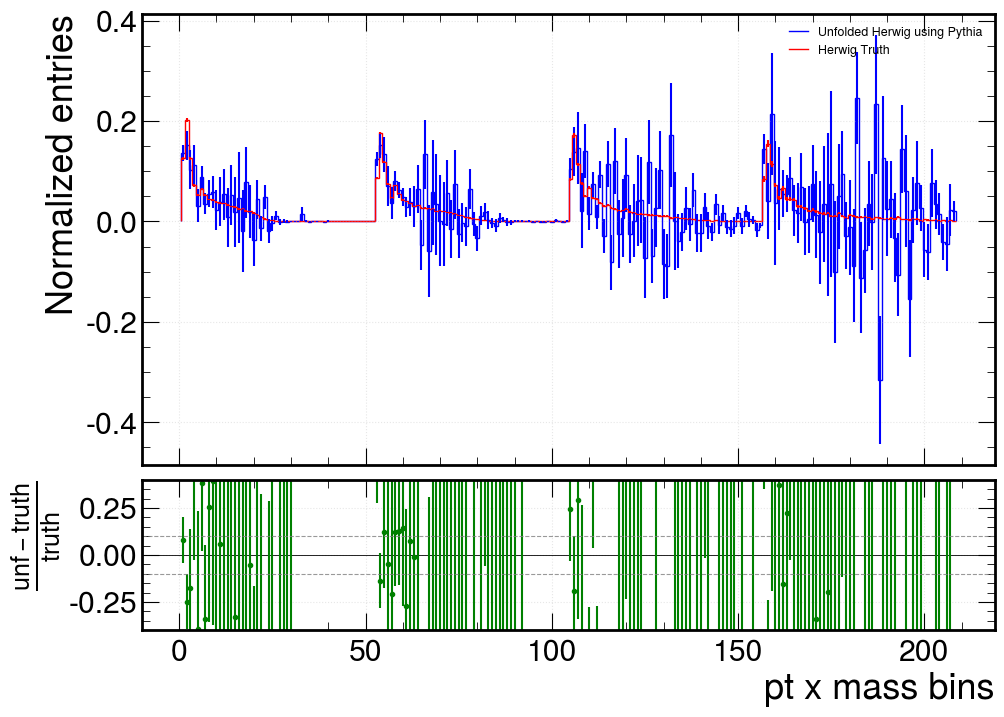

In [14]:
# extract TH1D 'output' into numpy arrays
if 'output' not in globals():
    raise NameError("Histogram 'output' not found in globals()")

nbins = int(output.GetNbinsX())

edges = np.array([output.GetXaxis().GetBinLowEdge(i) for i in range(1, nbins + 2)])
centers = np.array([output.GetXaxis().GetBinCenter(i) for i in range(1, nbins + 1)])
values = np.array([output.GetBinContent(i) for i in range(1, nbins + 1)])
errors = np.array([output.GetBinError(i) for i in range(1, nbins + 1)])

nbins_m = len(mgen_edges_pt[0]) - 1
sum_values = [np.sum(values[i*nbins_m + 1:(i+1)*nbins_m]) for i in range(len(pt_slices))]

for i in range(len(pt_slices)):
    if sum_values[i] != 0:
        values[i*nbins_m:(i+1)*nbins_m] /= sum_values[i]
        errors[i*nbins_m:(i+1)*nbins_m] /= sum_values[i]

# convenience container
vals2 = values  # keep name requested by the notebook if desired
vals2_edges = edges
vals2_centers = centers
vals2_err = errors

# normalize gen_vals2 & gen_vars2_ per pt slice (matching above)
for i in range(len(gen_vals2)):
    s = np.sum(gen_vals2[i][1:])  # skip underflow bin
    if s != 0:
        gen_vars2_[i] /= s**2
        gen_vals2[i] /= s

gen_flat = gen_vals2.flatten()
gen_var_flat = gen_vars2_.flatten()
gen_err_flat = np.sqrt(gen_var_flat)

# ratio and propagated uncertainty (approximate, treat uncertainties as independent)
mask = gen_flat > 0
ratio = np.full_like(gen_flat, np.nan)
ratio_err = np.full_like(gen_flat, np.nan)
ratio[mask] = (vals2[mask] - gen_flat[mask]) / gen_flat[mask]
ratio_err[mask] = np.sqrt(vals2_err[mask]**2 + gen_err_flat[mask]**2) / gen_flat[mask]

# Plot: main plot on top, ratio underneath with shared x
fig, (ax_main, ax_ratio) = plt.subplots(
    nrows=2, ncols=1, sharex=True, figsize=(11, 8),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# Main: unfolded vs truth
ax_main.stairs(vals2, vals2_edges, label='Unfolded Herwig using Pythia', color='b')
ax_main.errorbar(vals2_centers, vals2, yerr=vals2_err, fmt='none', ecolor='b', capsize=0)
ax_main.stairs(gen_flat, vals2_edges, label='Herwig Truth', color='r')
ax_main.errorbar(vals2_centers, gen_flat, yerr=gen_err_flat, fmt='none', ecolor='r', capsize=0)

ax_main.set_ylabel("Normalized entries")
ax_main.legend(fontsize=9)
ax_main.grid(alpha=0.3)

# Ratio plot
ax_ratio.axhline(0.0, color='k', lw=0.6)
ax_ratio.errorbar(vals2_centers, ratio, yerr=ratio_err, fmt='o', color='g', markersize=3, capsize=0)
ax_ratio.set_ylim(-0.4, 0.4)
ax_ratio.axhline(-0.1, color='gray', linestyle='--', lw=0.8, alpha=0.8)
ax_ratio.axhline(0.1,  color='gray', linestyle='--', lw=0.8, alpha=0.8)
ax_ratio.set_ylabel(r"$\frac{unf - truth}{truth}$")
ax_ratio.set_xlabel("pt x mass bins")
ax_ratio.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Extracted 40 bins: arrays vals2 (values), vals2_err (errors), vals2_centers, vals2_edges


Text(1, 0, 'pt x mass bins')

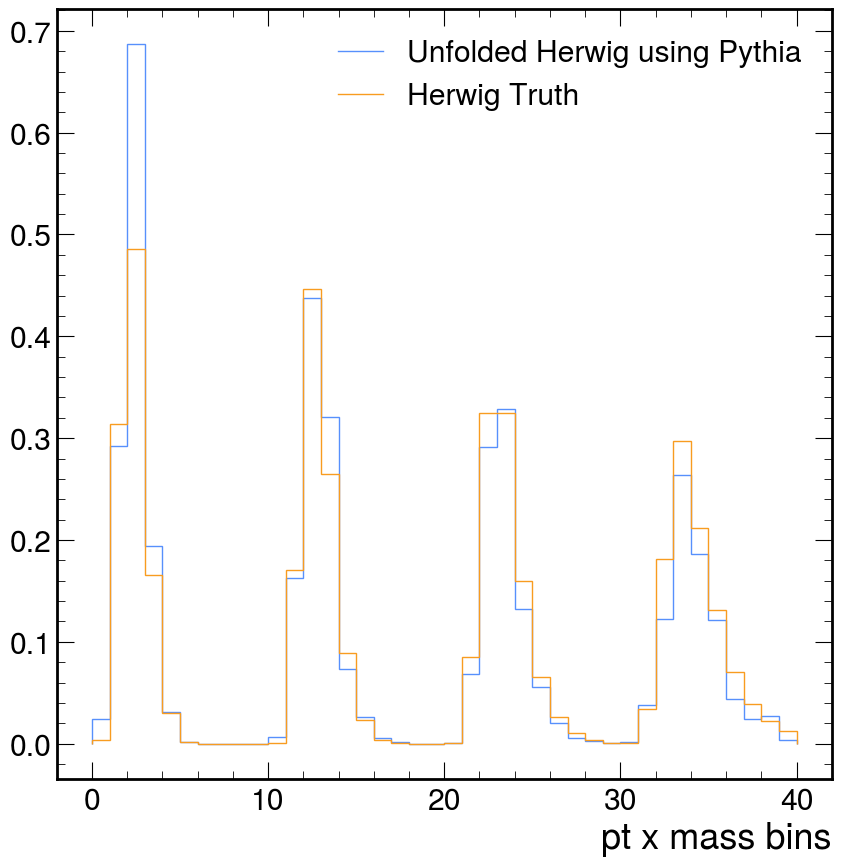

In [128]:
# extract TH1D 'output' into numpy arrays
if 'output' not in globals():
    raise NameError("Histogram 'output' not found in globals()")

nbins = int(output.GetNbinsX())

edges = np.array([output.GetXaxis().GetBinLowEdge(i) for i in range(1, nbins + 2)])
centers = np.array([output.GetXaxis().GetBinCenter(i) for i in range(1, nbins + 1)])
values = np.array([output.GetBinContent(i) for i in range(1, nbins + 1)])
errors = np.array([output.GetBinError(i) for i in range(1, nbins + 1)])

# convenience container
vals2 = values  # keep name requested by the notebook if desired
vals2_edges = edges
vals2_centers = centers
vals2_err = errors

print(f"Extracted {nbins} bins: arrays vals2 (values), vals2_err (errors), vals2_centers, vals2_edges")

plt.stairs(vals2, label = 'Unfolded Herwig using Pythia')
for i in range(len(gen_vals2)):
    gen_vals2[i] /= np.sum(gen_vals2[i])

plt.stairs(gen_vals2.flatten(), label = "Herwig Truth")
plt.legend()
plt.xlabel("pt x mass bins")

In [129]:
import numpy as np

# Extract bin contents and errors from the 'output' histogram
unfolded = np.array([output.GetBinContent(i) for i in range(1, output.GetNbinsX() + 1)])
unfolded_err = np.array([output.GetBinError(i) for i in range(1, output.GetNbinsX() + 1)])

# Save to .npz file using 'var' as the rebin_factor (assuming var=5.0 corresponds to rebin_factor=5)
np.savez(f"herwig_output_{int(rebin_factor)}.npz", unfolded=unfolded, unfolded_err=unfolded_err)

In [23]:
# use TH1::Clone to duplicate (provide a new name)
output_rebinned = output.Clone("output_rebinned")
y_rebinned = y.Clone("y_rebinned")
y_rebinned.Rebin(5)
output_rebinned.Rebin(5)
c3 = r.TCanvas('c3','c3',800,600)
output_rebinned.SetLineColor(r.kRed)
output_rebinned.Draw('E')
y_rebinned.Draw('same')
leg = r.TLegend(0.65, 0.75, 0.9, 0.9)
leg.AddEntry(output_rebinned, "Unfolded output", "l")
leg.AddEntry(y_rebinned, "Truth", "l")
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.Draw()
c3.Draw()

Warning in <TH1D::Rebin>: ngroup=5 is not an exact divider of nbins=208.
Warning in <TH1D::Rebin>: ngroup=5 is not an exact divider of nbins=208.
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c3


In [131]:

rebin_factors = [1, 2, 5, 10]
loaded_outputs = {}
for rf in rebin_factors:
    with np.load(f"herwig_output_{rf}.npz") as data:
        loaded_outputs[rf] = {key: data[key] for key in data.files}

fig, ax = plt.subplots(figsize=(8, 5))
for rf in rebin_factors:
    unfolded = loaded_outputs[rf]["unfolded"]
    unfolded_err = loaded_outputs[rf]["unfolded_err"]
    bins = np.arange(len(unfolded))
    ax.errorbar(
        bins,
        unfolded,
        yerr=unfolded_err,
        xerr=0.5,
        label=f"Herwig rebin {rf}",
        marker="",
        linestyle="",
        capsize=0,
    )

ax.set_xlabel("Unfolded bin")
ax.set_ylabel("Entries")
ax.set_title("Herwig unfolded comparison")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()



FileNotFoundError: [Errno 2] No such file or directory: 'herwig_output_1.npz'

In [49]:
import plotly.graph_objects as go

import plotly.graph_objects as go

fig = go.Figure()
for rf in rebin_factors:
    unfolded = loaded_outputs[rf]["unfolded"]
    unfolded_err = loaded_outputs[rf]["unfolded_err"]
    bins = np.arange(len(unfolded))
    fig.add_trace(go.Scatter(
        x=bins,
        y=unfolded,
        error_y=dict(type='data', array=unfolded_err, visible=True),
        error_x=dict(type='data', array=[0.5]*len(bins), visible=True),
        mode='markers',
        name=f"Herwig rebin {rf}",
        marker=dict(size=5)
    ))

fig.update_layout(
    title="Herwig unfolded comparison",
    xaxis_title="Unfolded bin",
    yaxis_title="Entries",
    showlegend=True,
    width=800  # Set width to half of a typical screen (assuming 1600px), adjust as needed
)
fig.show()

